In [142]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv(r"D:\Jupiter\E-commerce_project\data\Ecommerce_clean.csv", encoding="UTF-8")


# Category Performance

**Sales by Category**

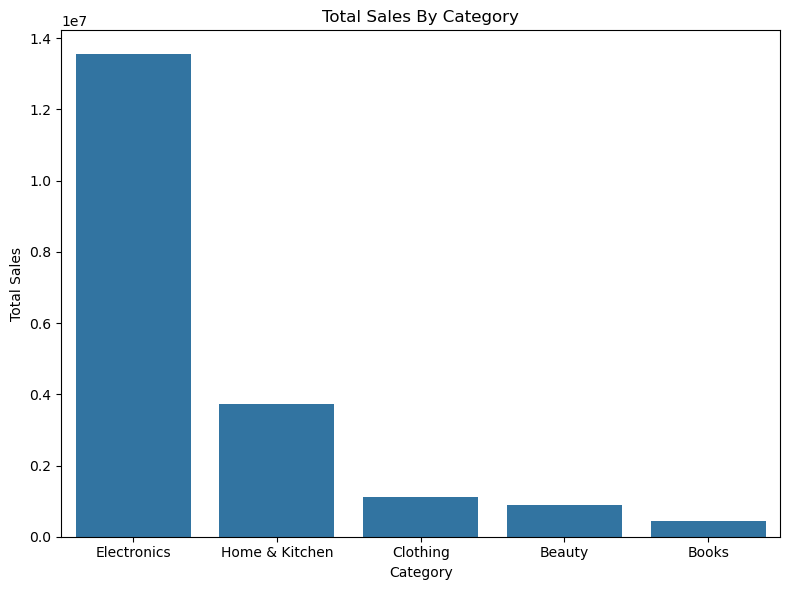

In [144]:
category_sales = df.groupby("category")["sales"].sum().sort_values(ascending=False)
plt.figure(figsize=(8,6))

sns.barplot(x = category_sales.index, y = category_sales.values)
plt.title("Total Sales By Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

**Profit by Category**

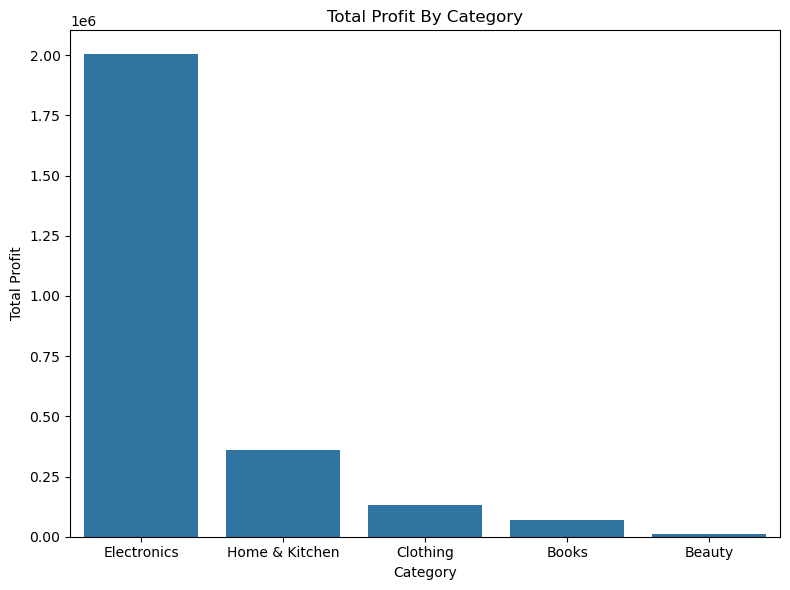

In [145]:
category_profit = df.groupby("category")["profit"].sum().sort_values(ascending=False)
plt.figure(figsize=(8,6))
sns.barplot(x=category_profit.index, y = category_profit.values)
plt.title("Total Profit By Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.tight_layout()
plt.show()


**Sales vs Profit by Category**

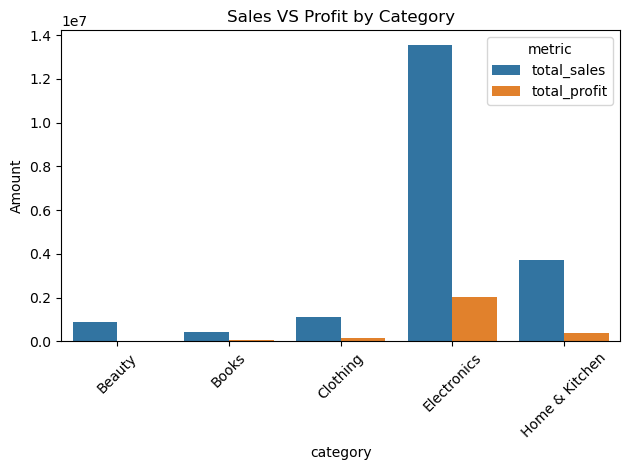

In [146]:
category_Summary = df.groupby("category").agg(
    total_sales = ("sales", "sum"),
    total_profit = ("profit", "sum")
)
category_Summary = category_Summary.reset_index()

category_melted = category_Summary.melt(
    id_vars="category",
    value_vars=["total_sales", "total_profit"],
    var_name="metric",
    value_name="amount"
)


sns.barplot(
    data=category_melted,
    x="category",
    y="amount",
    hue="metric"
)
plt.title("Sales VS Profit by Category")
plt.xlabel("category")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Product Performance

**Top 10 Products by Sales**

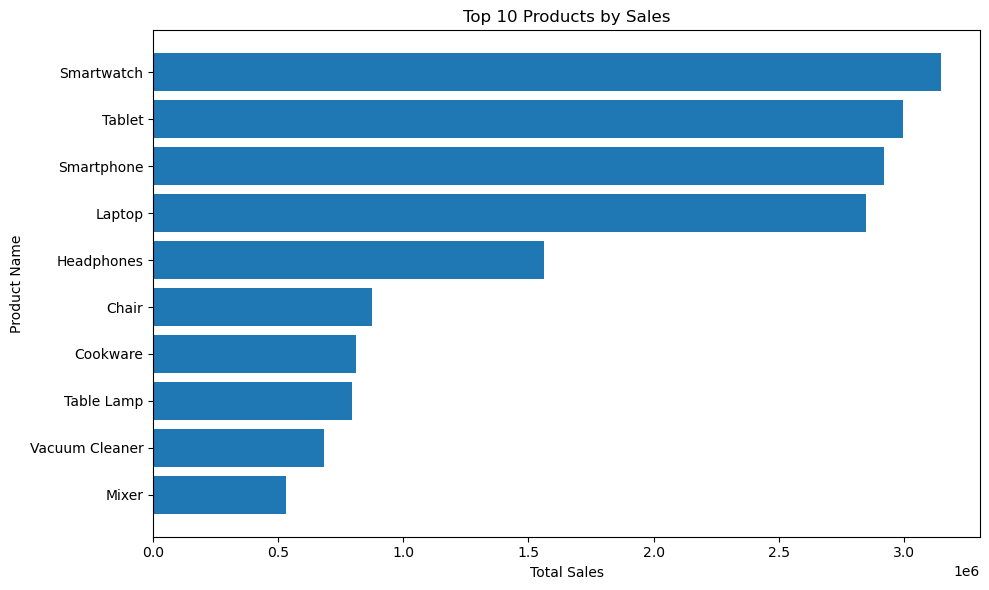

In [147]:
top_sales_product = df.groupby("product_name")["sales"].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))

plt.barh(
    y=top_sales_product.index,
    width=top_sales_product.values
)

plt.gca().invert_yaxis()

plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product Name")

plt.tight_layout()
plt.show()

**Top 10 Products by Profit**

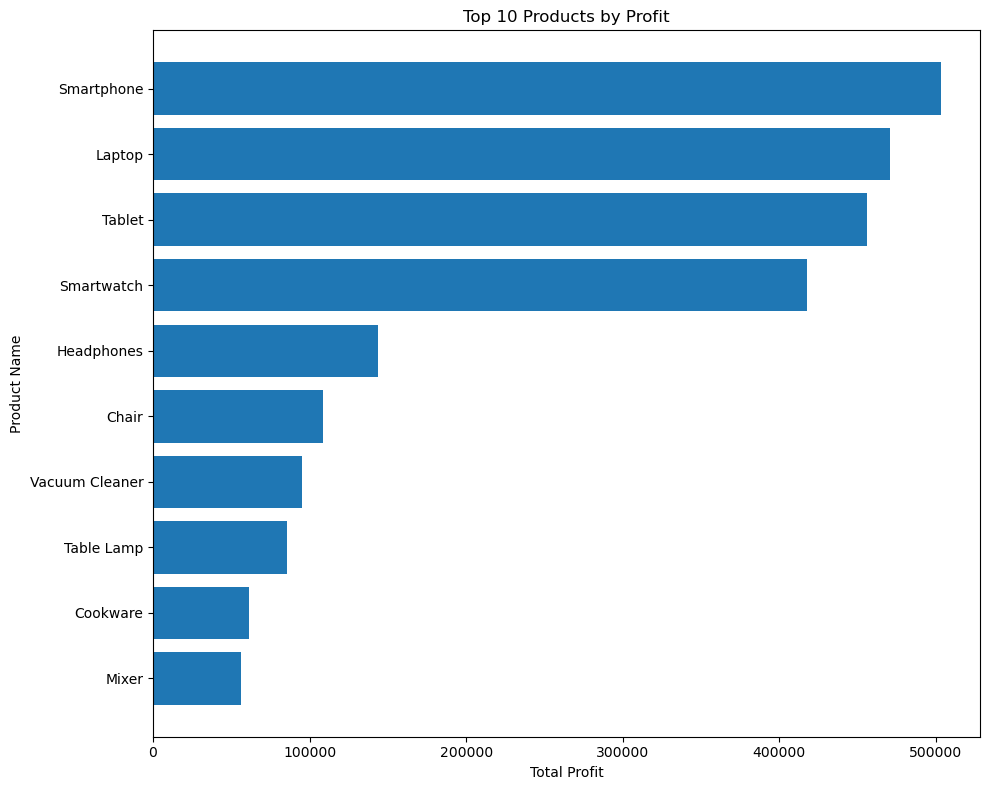

In [148]:
top_profit_profit = df.groupby("product_name")["profit"].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 8))

plt.barh(top_profit_profit.index, top_profit_profit.values)
plt.gca().invert_yaxis()
plt.title("Top 10 Products by Profit")
plt.xlabel("Total Profit")
plt.ylabel("Product Name")
plt.tight_layout()
plt.show()

# Geographic Analysis

**Top 10 States by Sales**

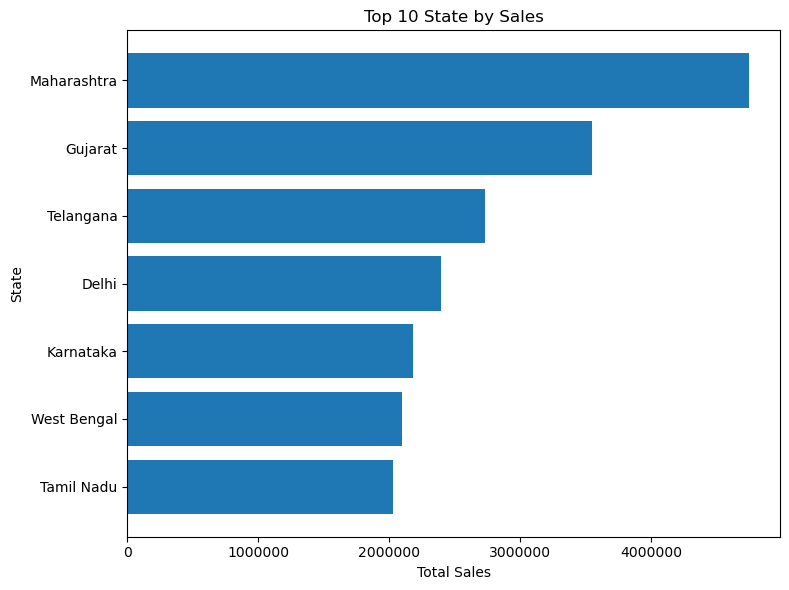

In [149]:
top_state_sales = df.groupby("state")["sales"].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(8,6))
bars = plt.barh(top_state_sales.index, top_state_sales.values)
plt.gca().invert_yaxis()
plt.title("Top 10 State by Sales")
plt.xlabel("Total Sales")
plt.ticklabel_format(
    style="plain",
    axis="x"
)
plt.ylabel("State")
plt.tight_layout()
plt.show()

**Top 10 Cities by Profit**

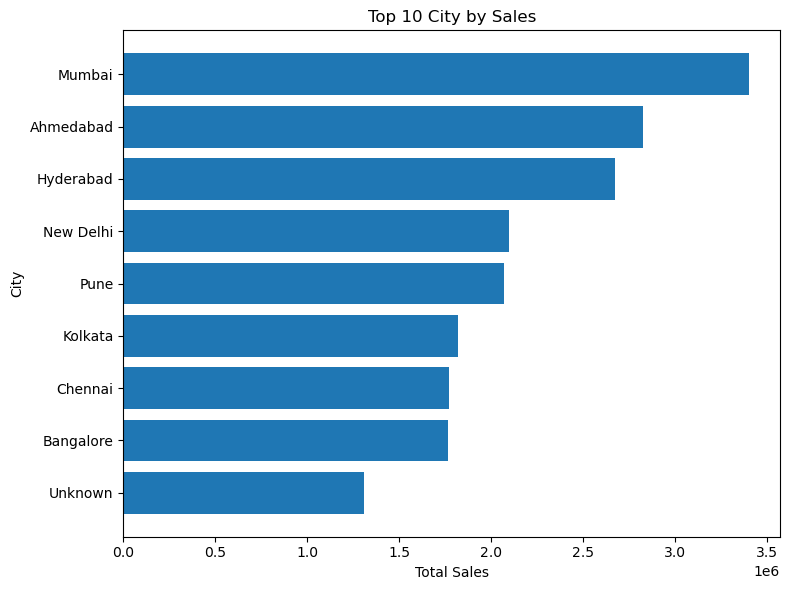

In [150]:
top_city_sales = df.groupby("city")["sales"].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(8,6))
plt.barh(top_city_sales.index, top_city_sales.values)
plt.gca().invert_yaxis()
plt.title("Top 10 City by Sales")
plt.xlabel("Total Sales")
plt.ylabel("City")
plt.tight_layout()
plt.show()

# Customer Analysis

**Top 10 Customers by Spending**

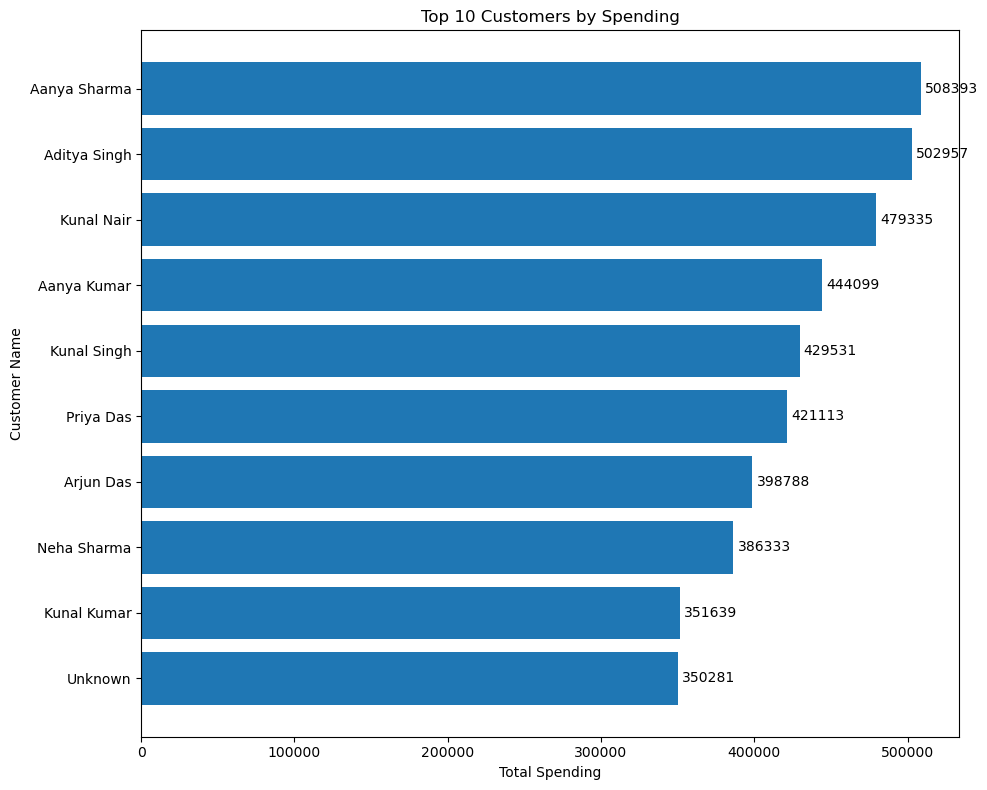

In [151]:
top_customer_spending = df.groupby("customer_name")["sales"].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,8))
bars = plt.barh(top_customer_spending.index, top_customer_spending.values)
plt.gca().invert_yaxis()
plt.bar_label(
    bars,
    fmt="%.0f",
    padding=3
)
plt.title("Top 10 Customers by Spending")
plt.xlabel("Total Spending")
plt.ylabel("Customer Name")
plt.tight_layout()
plt.show()

**Customer Age Distribution**

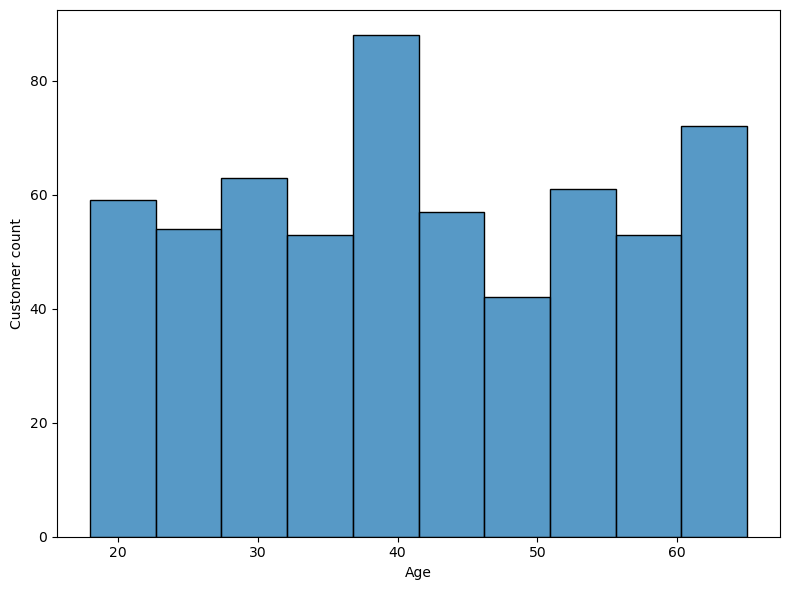

In [152]:
plt.figure(figsize=(8,6))
sns.histplot(data=df, x="age", bins=10)
plt.xlabel("Age")
plt.ylabel("Customer count")
plt.tight_layout()
plt.show()

**Sales by Gender**

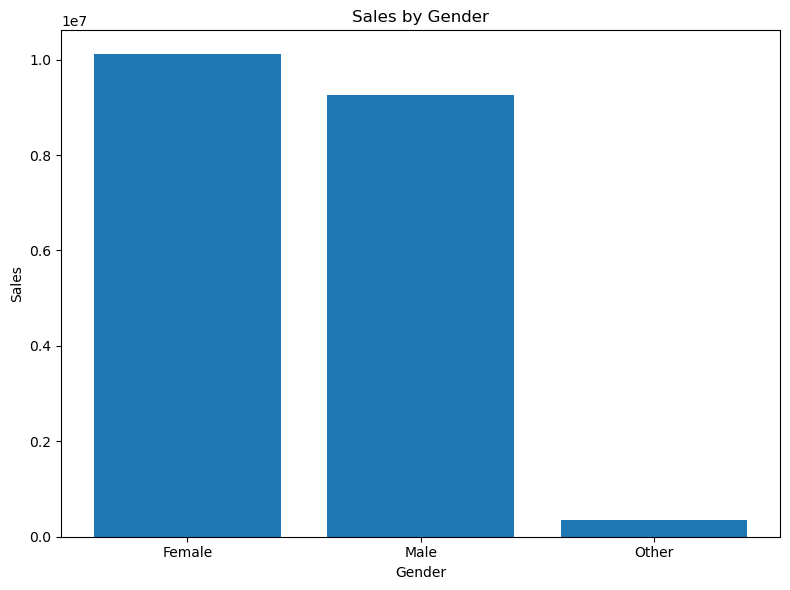

In [153]:
sales_by_gender = df.groupby("gender")["sales"].sum().sort_values(ascending=False)
plt.figure(figsize=(8,6))
plt.bar(sales_by_gender.index, sales_by_gender.values)
plt.title("Sales by Gender")
plt.xlabel("Gender")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

# Discount Analysis

**Discount Percentage vs Profit**

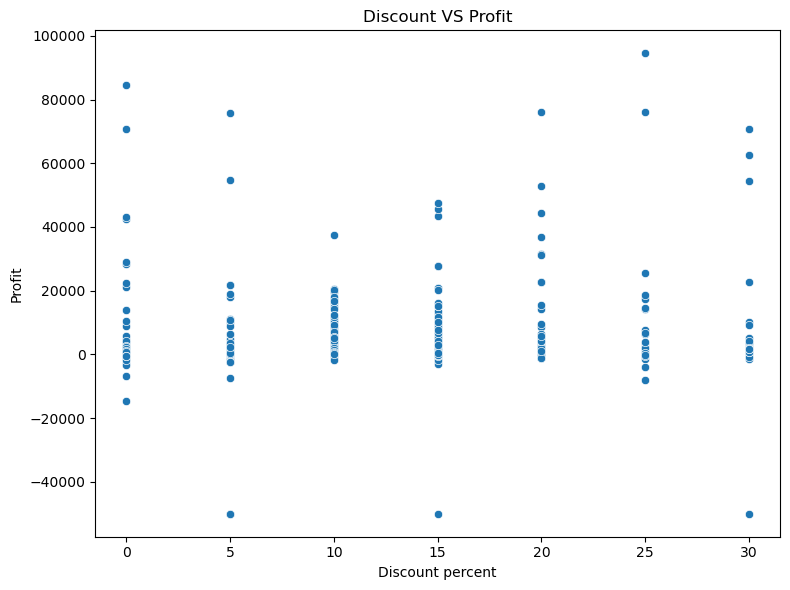

In [154]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="discount_percent", y="profit")
plt.title("Discount VS Profit")
plt.xlabel("Discount percent")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

**Discount Percentage vs Sales**

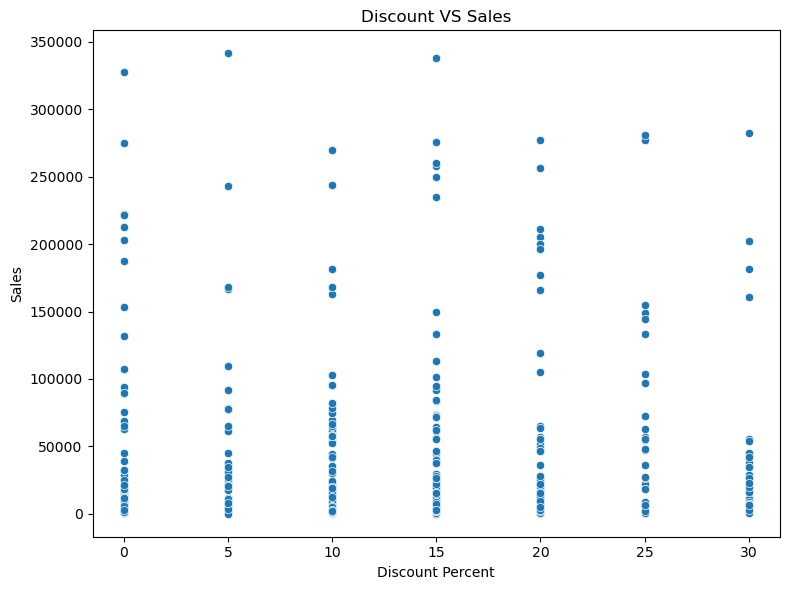

In [155]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="discount_percent", y="sales")
plt.title("Discount VS Sales")
plt.xlabel("Discount Percent")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()


**Profit by Discount Percentage**

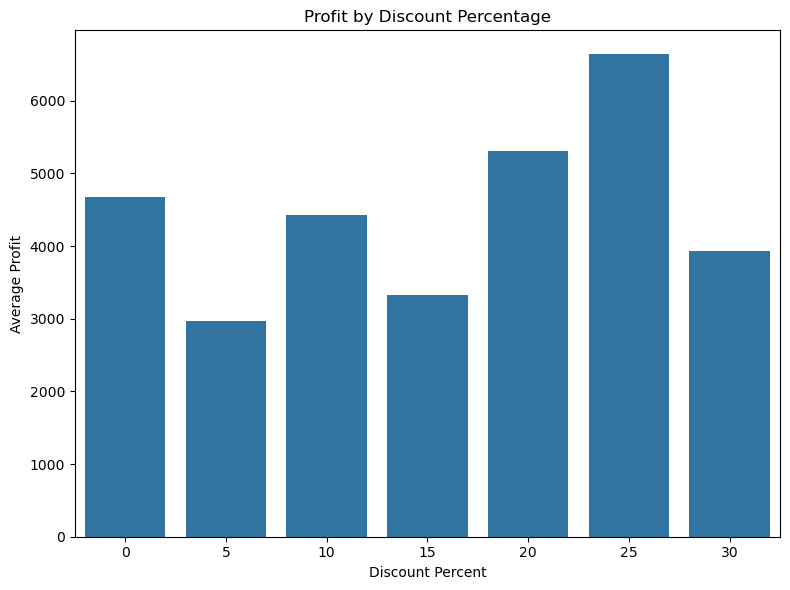

In [156]:
plt.figure(figsize=(8,6))
sns.barplot(data=df, x="discount_percent", y="profit", errorbar=None)
plt.title("Profit by Discount Percentage")
plt.xlabel("Discount Percent")
plt.ylabel("Average Profit")

plt.tight_layout()
plt.show()

# Payment & Order Analysis

**Sales by Payment Method**

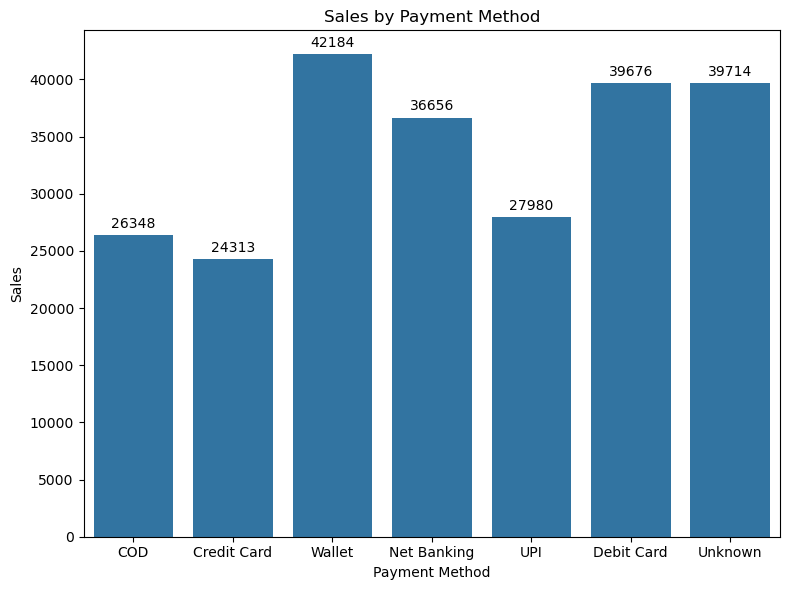

In [157]:
plt.figure(figsize=(8,6))
ax = sns.barplot(data=df, x="payment_method", y="sales", errorbar=None)
plt.bar_label(
    ax.containers[0],
    fmt="%.0f",
    padding=3
)
plt.title("Sales by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

**Order Status Distribution By PIE Chart**

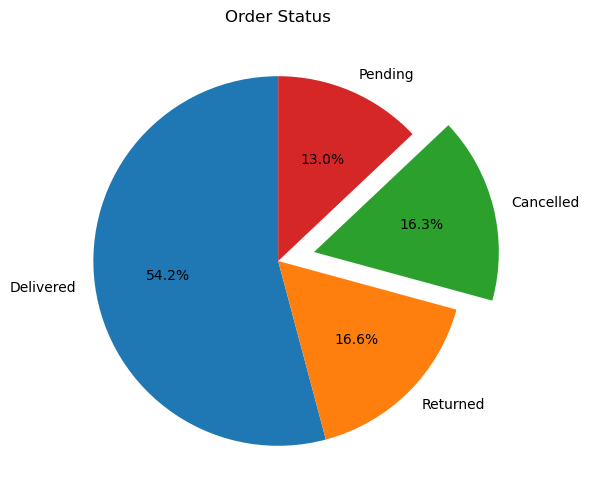

In [158]:
order_status = df["order_status"].value_counts()
order_status
plt.figure(figsize=(6,6))
plt.pie(order_status.values,labels=order_status.index,autopct="%1.1f%%", startangle=90, explode=(0, 0, 0.2, 0))
plt.title("Order Status")
plt.show()


**Order Status Distribution By Bar Chart**

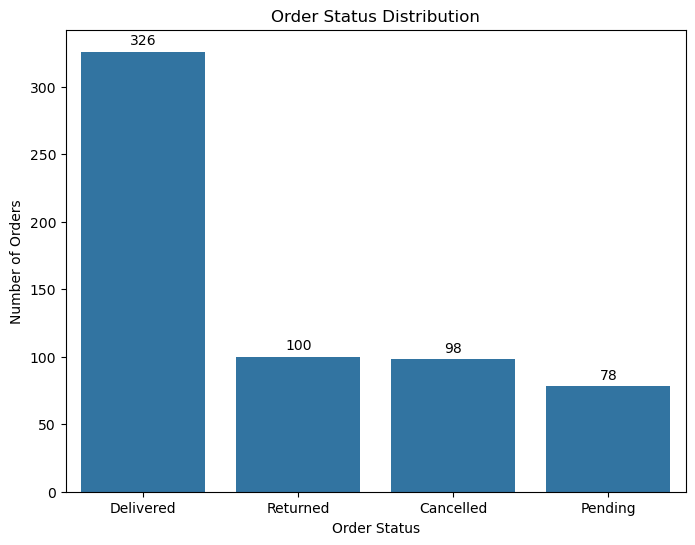

In [159]:
plt.figure(figsize=(8,6))
ax = sns.barplot(x=order_status.index, y=order_status.values)
plt.bar_label(
    ax.containers[0],
    fmt="%.0f",
    padding=3
)
plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.show()

**Profit by Order Status**

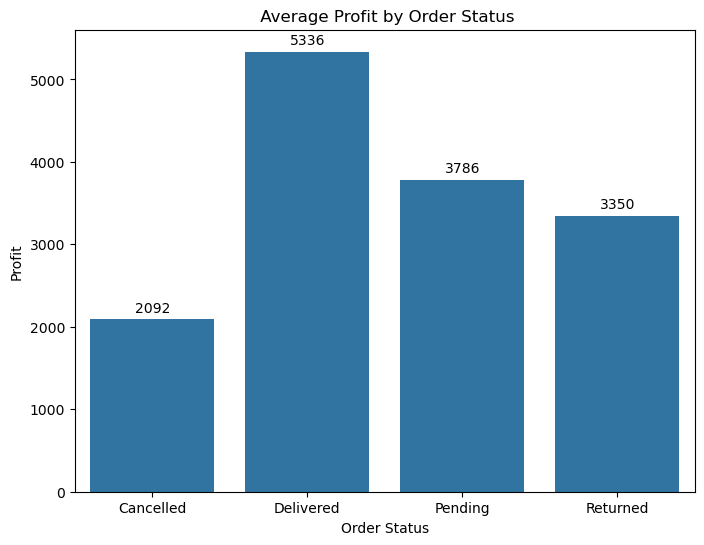

In [160]:
plt.figure(figsize=(8,6))
ax = sns.barplot(data=df, x="order_status", y="profit", errorbar=None)
plt.bar_label(
    ax.containers[0],
    fmt="%.0f",
    padding=3
)
plt.title(" Average Profit by Order Status")
plt.xlabel("Order Status")
plt.ylabel("Profit")
plt.show()


# Time-Series Analysis

**Monthly Sales Trend**

C:\Users\rishi\AppData\Local\Temp\ipykernel_22596\1128381918.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["order_date"] = pd.to_datetime(df["order_date"])


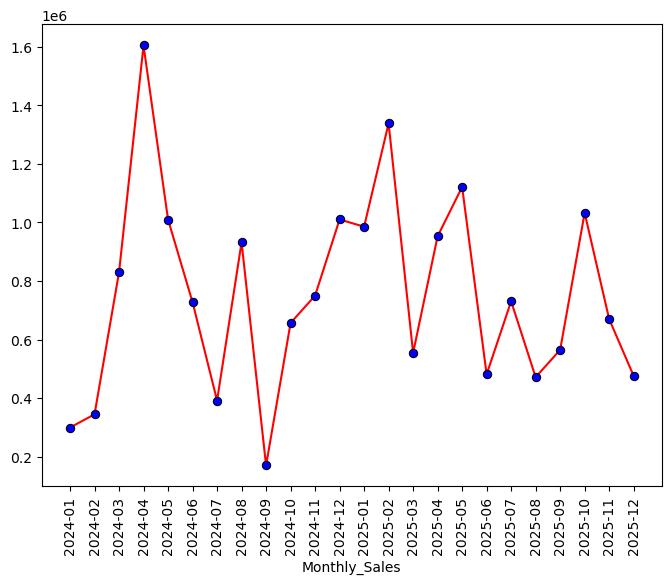

In [161]:
df["order_date"] = pd.to_datetime(df["order_date"])
df["year_month"] = df["order_date"].dt.to_period("M")
monthly_sales =  df.groupby("year_month")["sales"].sum().sort_index()
plt.figure(figsize=(8,6))
sns.lineplot(x=monthly_sales.index.astype(str), y=monthly_sales.values, marker="o", color="red", markerfacecolor="blue", markeredgecolor="black")
plt.xticks(rotation=90)
plt.xlabel("Monthly_Sales")
plt.show()

**Monthly Profit Trend**

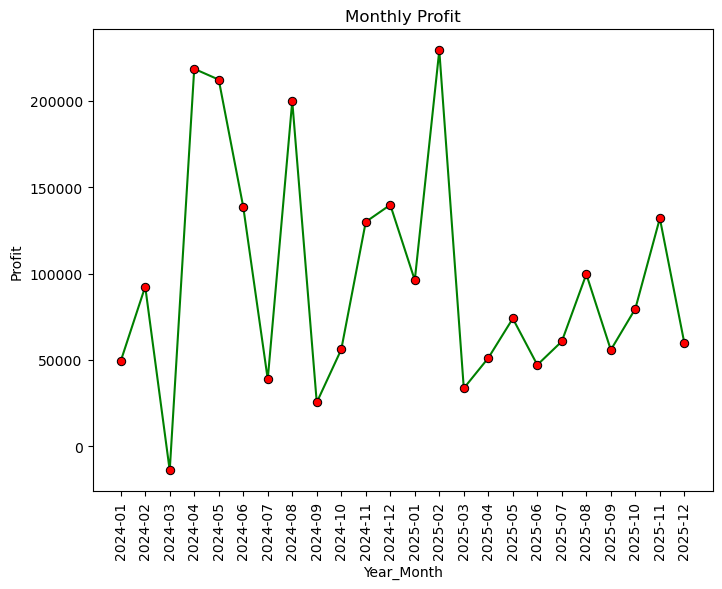

In [162]:
monthly_profit = df.groupby("year_month")["profit"].sum().sort_index()
plt.figure(figsize=(8,6))
sns.lineplot(x=monthly_profit.index.astype(str), y=monthly_profit.values, marker="o", color="green", markerfacecolor="red", markeredgecolor="black")
plt.xticks(rotation=90)
plt.title("Monthly Profit")
plt.xlabel("Year_Month")
plt.ylabel("Profit")
plt.show()

**Monthly Sales vs Profit**

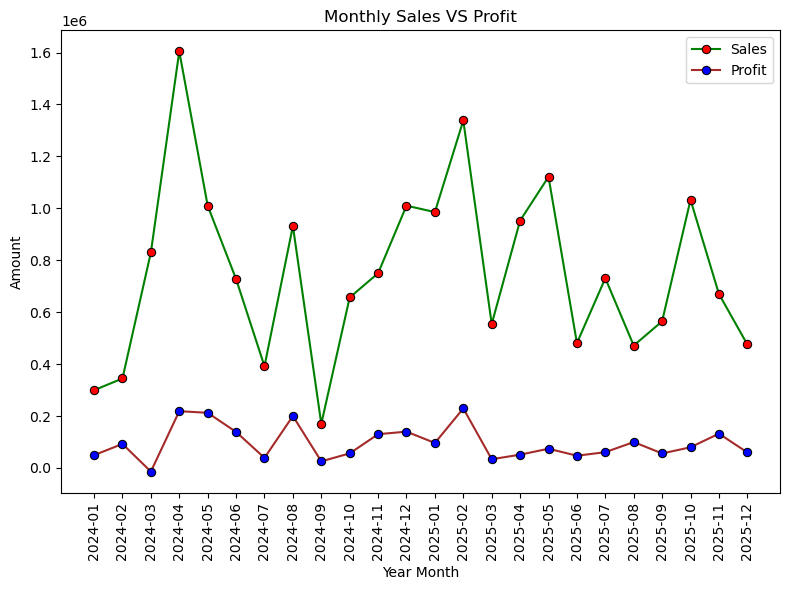

In [163]:
plt.figure(figsize=(8,6))
sns.lineplot(x=monthly_sales.index.astype(str),
             y=monthly_sales.values,
             marker="o",
             label="Sales",
             color="green",
             markerfacecolor="red",
             markeredgecolor="black"
)

sns.lineplot(x=monthly_profit.index.astype(str),
             y=monthly_profit.values,
             marker="o",
             label="Profit",
             color="brown",
             markerfacecolor="blue",
             markeredgecolor="black"
)

plt.title("Monthly Sales VS Profit")
plt.xlabel("Year Month")
plt.ylabel("Amount")
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

# Delivery Analysis

**Average Delivery Time by State**

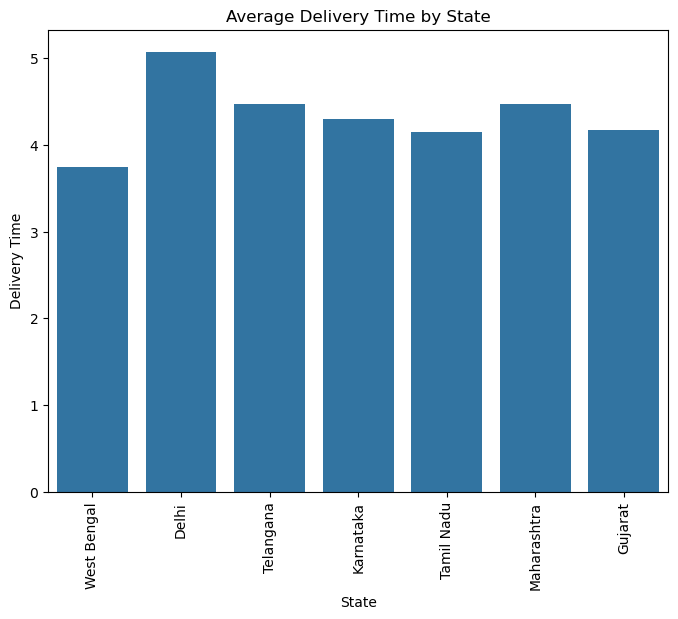

In [164]:
df["delivery_date"] = pd.to_datetime(df["delivery_date"])
df["delivery_days"] = (df["delivery_date"] - df["order_date"]).dt.days
plt.figure(figsize=(8,6))
sns.barplot(data=df, x="state", y="delivery_days", errorbar=None)
plt.title("Average Delivery Time by State")
plt.xlabel("State")
plt.ylabel("Delivery Time")
plt.xticks(rotation=90)
plt.show()

**Average Delivery Time by Order Status**

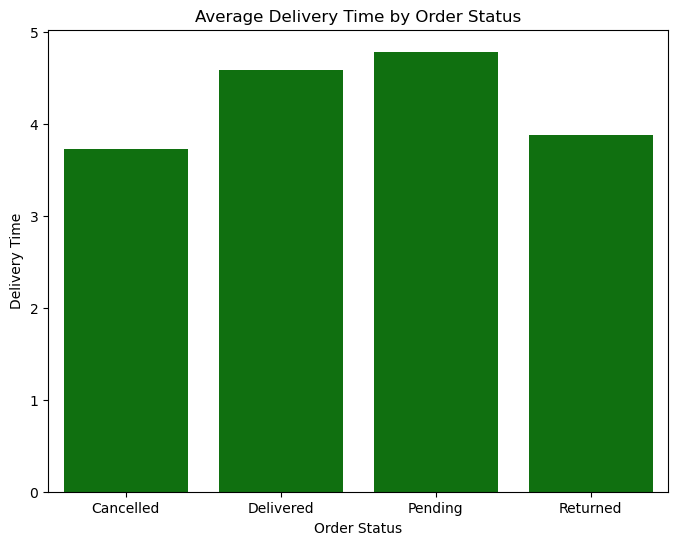

In [165]:
plt.figure(figsize=(8,6))
sns.barplot(data=df, x="order_status", y="delivery_days", errorbar=None, color="green")
plt.title("Average Delivery Time by Order Status")
plt.xlabel("Order Status")
plt.ylabel("Delivery Time")
plt.show()

# Final Relationship Graphs


**Sales VS Profit**

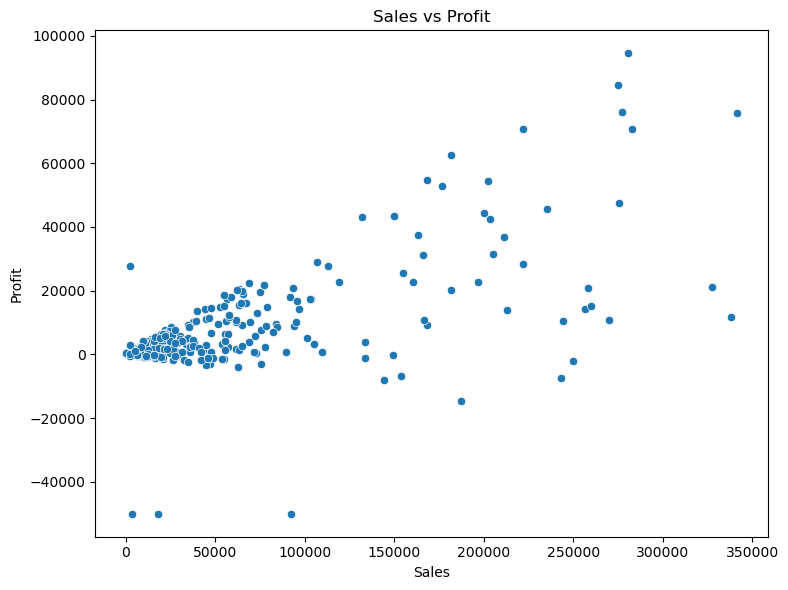

In [166]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="sales", y="profit")
plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()


**Quantity VS Sales**

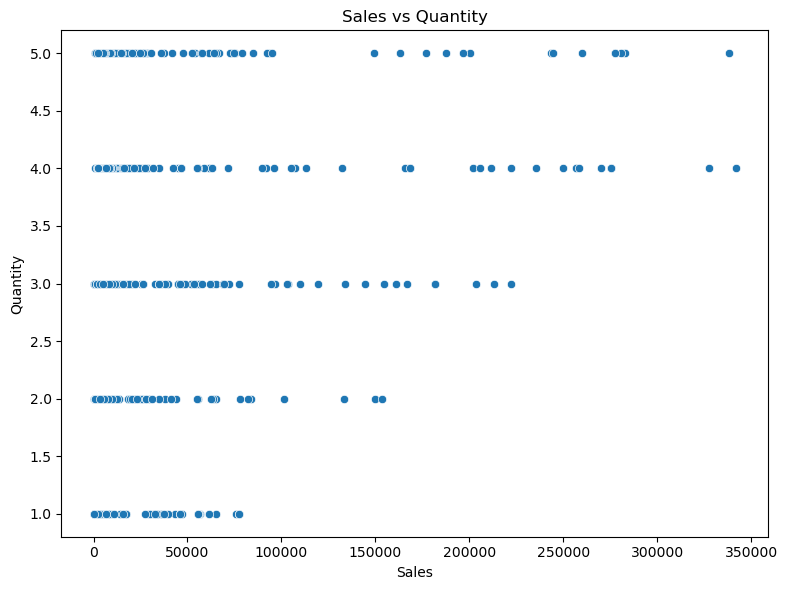

In [167]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="sales", y="quantity")
plt.title("Sales vs Quantity")
plt.xlabel("Sales")
plt.ylabel("Quantity")

plt.tight_layout()
plt.show()

**Correlation Heatmap**

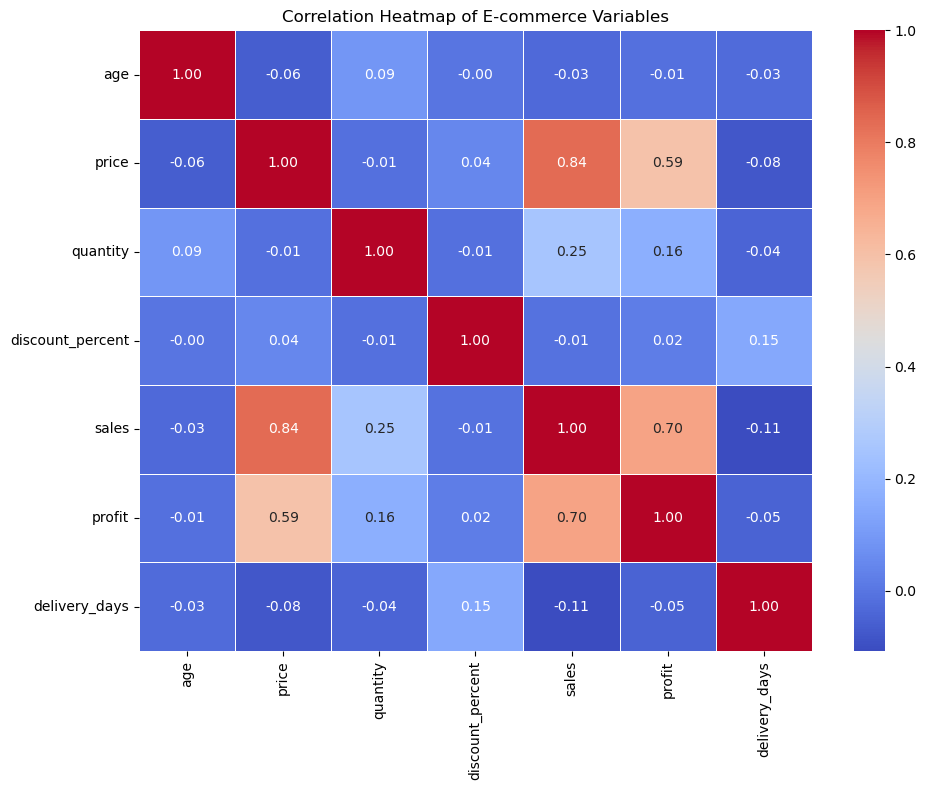

In [168]:
numeric_columns = [
    "age",
    "price",
    "quantity",
    "discount_percent",
    "sales",
    "profit",
    "delivery_days"
]
correlation = df[numeric_columns].corr()
plt.figure(figsize=(10,8))
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Heatmap of E-commerce Variables")

plt.tight_layout()
plt.show()